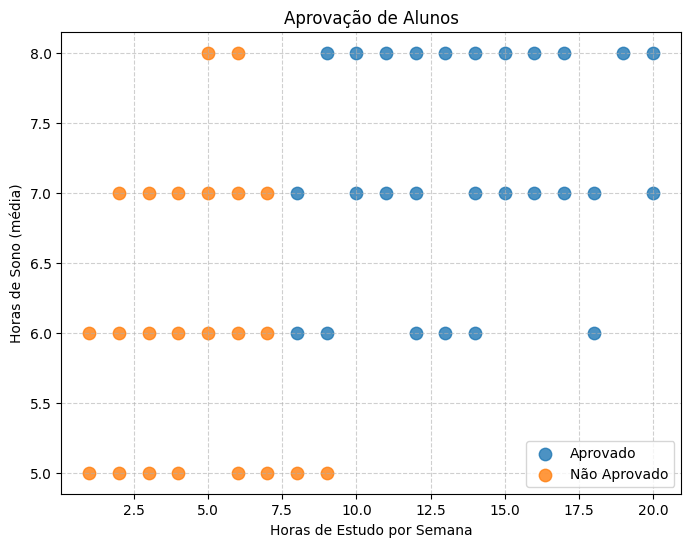

In [11]:
# Exemplo KNN - Leitura + Scatter
import pandas as pd
import matplotlib.pyplot as plt

SHEET_ID = "14D-PIZuQ4Ac3_92iyO4AwCmF4NMrh0VHK6Kkk1r5KTg"
GID = "0"

url_tsv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=tsv&gid={GID}"

df = pd.read_csv(url_tsv, sep="\t")

for col in ["Horas_Estudo_Semana", "Horas_Sono_Media"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

aprovados = df[df["Aprovados"] == "Sim"]
reprovados = df[df["Aprovados"] == "Nao"]

plt.figure(figsize=(8,6))

plt.scatter(
    aprovados["Horas_Estudo_Semana"],
    aprovados["Horas_Sono_Media"],
    label="Aprovado",
    s=80,
    alpha=0.8
)

plt.scatter(
    reprovados["Horas_Estudo_Semana"],
    reprovados["Horas_Sono_Media"],
    label="Não Aprovado",
    s=80,
    alpha=0.8
)

plt.xlabel("Horas de Estudo por Semana")
plt.ylabel("Horas de Sono (média)")
plt.title("Aprovação de Alunos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


=== Árvore de decisão ===
Features usadas: ['Horas_Estudo_Semana', 'Horas_Sono_Media']
Acurácia: 1.0

Relatório:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         8

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Matriz de confusão (real x previsto):
[[7 0]
 [0 8]]


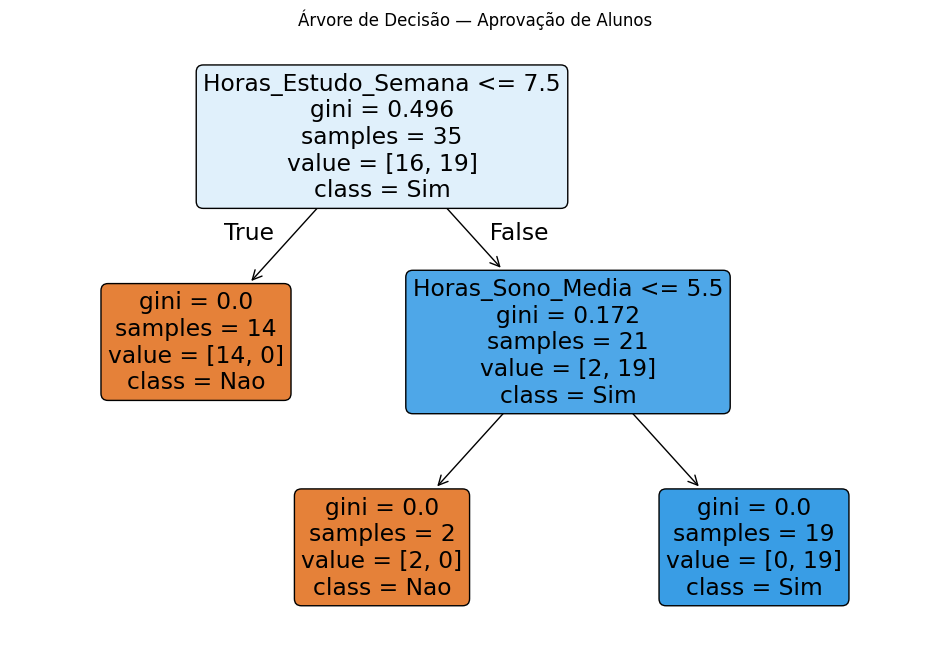

In [12]:
# ========= Árvore de decisão =========
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# ====== Preparação dos dados ======

# Converte classe para número
df["Aprovados"] = df["Aprovados"].map({"Sim": 1, "Nao": 0})

FEATURES = ["Horas_Estudo_Semana", "Horas_Sono_Media"]
TARGET = "Aprovados"

X = df[FEATURES]
y = df[TARGET]

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

# ====== Modelo ======
tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

# Treinamento
tree.fit(X_train, y_train)

# Previsão
y_pred_tree = tree.predict(X_test)

# ====== Avaliação ======
print("\n=== Árvore de decisão ===")
print("Features usadas:", FEATURES)
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório:")
print(classification_report(y_test, y_pred_tree))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

# ====== Desenhar a árvore ======
plt.figure(figsize=(12, 8))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=["Nao", "Sim"],
    filled=True,
    rounded=True,
    impurity=True
)

plt.title("Árvore de Decisão — Aprovação de Alunos")
plt.show()